In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [5]:
data = pd.read_csv('googleplaystore.csv', sep=",")

In [6]:
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [4]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 10841


In [15]:
data_new_2 = data.dropna(axis=0, how='any').copy()
(data.shape, data_new_2.shape)

((10841, 14), (7723, 14))

In [16]:
data_new_2.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64

In [17]:
data_new_2.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


C:\Users\masha\AppData\Local\Temp\ipykernel_7508\254853263.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_new_2['Rating'])


<Axes: xlabel='Rating', ylabel='Density'>

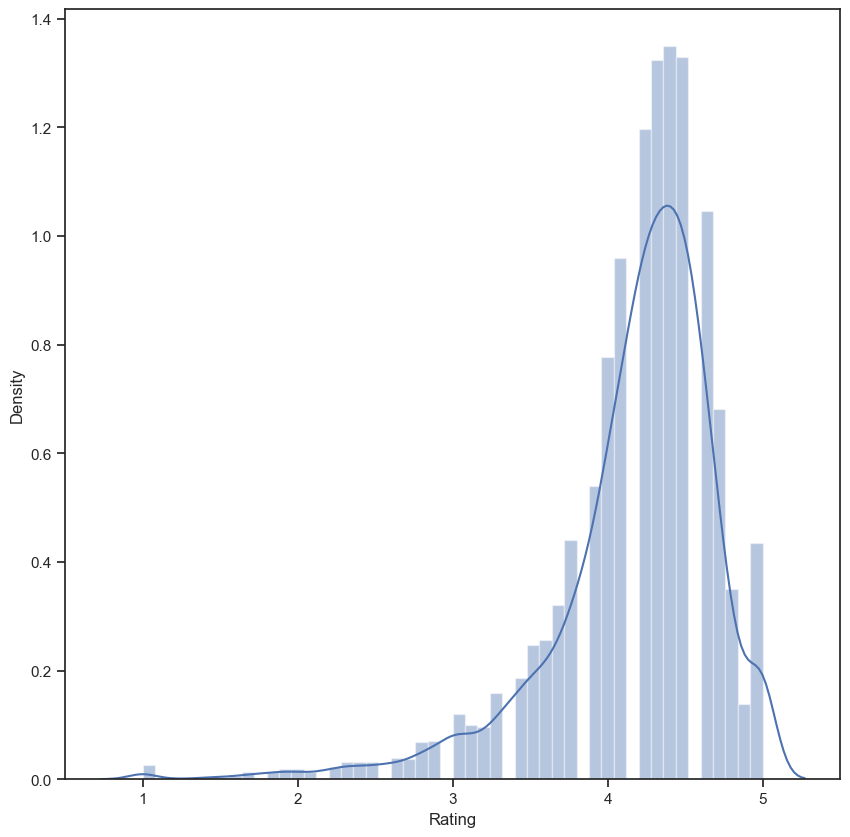

In [18]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.distplot(data_new_2['Rating'])

           Rating   Reviews   Size_MB     Price
Rating   1.000000  0.079819  0.083640 -0.021320
Reviews  0.079819  1.000000  0.240382 -0.010184
Size_MB  0.083640  0.240382  1.000000 -0.026272
Price   -0.021320 -0.010184 -0.026272  1.000000


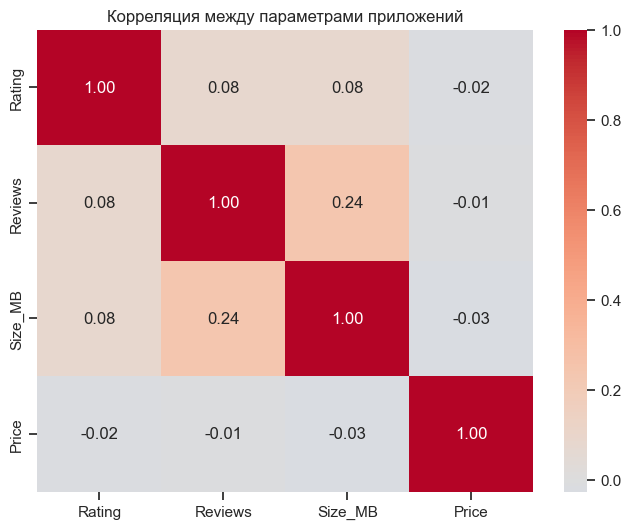

In [20]:
# Очищаем Price от символа $ в data_new_2
data_new_2['Price'] = data_new_2['Price'].astype(str).str.replace('$', '')
data_new_2['Price'] = pd.to_numeric(data_new_2['Price'], errors='coerce')

# Очищаем Reviews от запятых в data_new_2
data_new_2['Reviews'] = data_new_2['Reviews'].astype(str).str.replace(',', '')
data_new_2['Reviews'] = pd.to_numeric(data_new_2['Reviews'], errors='coerce')

data_new_2['Size_MB'] = data_new_2['Size'].apply(clean_size)


# Корреляция
correlation = data_clean[['Rating', 'Reviews', 'Size_MB', 'Price']].corr()
print(correlation)

# Тепловая карта
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция между параметрами приложений')
plt.show()